In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)

In [8]:
df = pd.read_csv('XAU_1d_data.csv', sep=';')

In [9]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2004.06.11 00:00,384.0,384.8,382.8,384.1,272
1,2004.06.14 00:00,384.3,385.8,381.8,382.8,1902
2,2004.06.15 00:00,382.8,388.8,381.1,388.6,1951
3,2004.06.16 00:00,387.1,389.8,382.6,383.8,2014
4,2004.06.17 00:00,383.6,389.3,383.0,387.6,1568


In [10]:
print("Shape of Data:", df.shape)

Shape of Data: (5531, 6)


In [11]:
print("\n--- Data Info ---")
df.info()



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5531 entries, 0 to 5530
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5531 non-null   object 
 1   Open    5531 non-null   float64
 2   High    5531 non-null   float64
 3   Low     5531 non-null   float64
 4   Close   5531 non-null   float64
 5   Volume  5531 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 259.4+ KB


In [12]:
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicated Rows Count:", df.duplicated().sum())



Missing Values:
 Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Duplicated Rows Count: 0


In [13]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y.%m.%d %H:%M')
df = df.sort_values('Date').reset_index(drop=True)


In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5531 entries, 0 to 5530
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    5531 non-null   datetime64[ns]
 1   Open    5531 non-null   float64       
 2   High    5531 non-null   float64       
 3   Low     5531 non-null   float64       
 4   Close   5531 non-null   float64       
 5   Volume  5531 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 259.4 KB


In [15]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()
#--------------------------------------------

In [16]:
df['Daily_Range'] = df['High'] - df['Low']
df['Daily_Change'] = df['Close'] - df['Open']
df['Daily_Return_%'] = df['Close'].pct_change() * 100

In [17]:
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

df.head()

,Date,Open,High,Low,Close,Volume,Year,Month,DayOfWeek,Daily_Range,Daily_Change,Daily_Return_%,MA50,MA200
0,2004-06-11,384.0,384.8,382.8,384.1,272,2004,6,Friday,2.0,0.1,NaN,NaN,NaN
1,2004-06-14,384.3,385.8,381.8,382.8,1902,2004,6,Monday,4.0,-1.5,-0.338454,NaN,NaN
2,2004-06-15,382.8,388.8,381.1,388.6,1951,2004,6,Tuesday,7.7,5.8,1.515152,NaN,NaN
3,2004-06-16,387.1,389.8,382.6,383.8,2014,2004,6,Wednesday,7.2,-3.3,-1.235203,NaN,NaN
4,2004-06-17,383.6,389.3,383.0,387.6,1568,2004,6,Thursday,6.3,4.0,0.990099,NaN,NaN


In [18]:
df[['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Range', 'Daily_Return_%']].describe().T

,count,mean,std,min,25%,50%,75%,max
Open,5531.0,1414.364431,673.568005,382.800000,1064.830000,1301.410000,1747.755000,5.421430e+03
High,5531.0,1425.083676,679.828757,384.800000,1073.240000,1309.060000,1758.935000,5.597600e+03
Low,5531.0,1403.521732,667.547425,381.100000,1058.330000,1292.060000,1732.570000,5.157040e+03
Close,5531.0,1414.756026,674.284364,382.800000,1064.360000,1301.840000,1747.245000,5.414460e+03
Volume,5531.0,88284.990960,126008.326343,2.000000,26856.000000,72918.000000,112720.500000,3.379613e+06
Daily_Range,5531.0,21.561944,21.526365,0.500000,11.050000,16.960000,25.795000,7.709300e+02
Daily_Return_%,5530.0,0.052200,1.113299,-9.066766,-0.484462,0.061015,0.619315,1.550805e+01


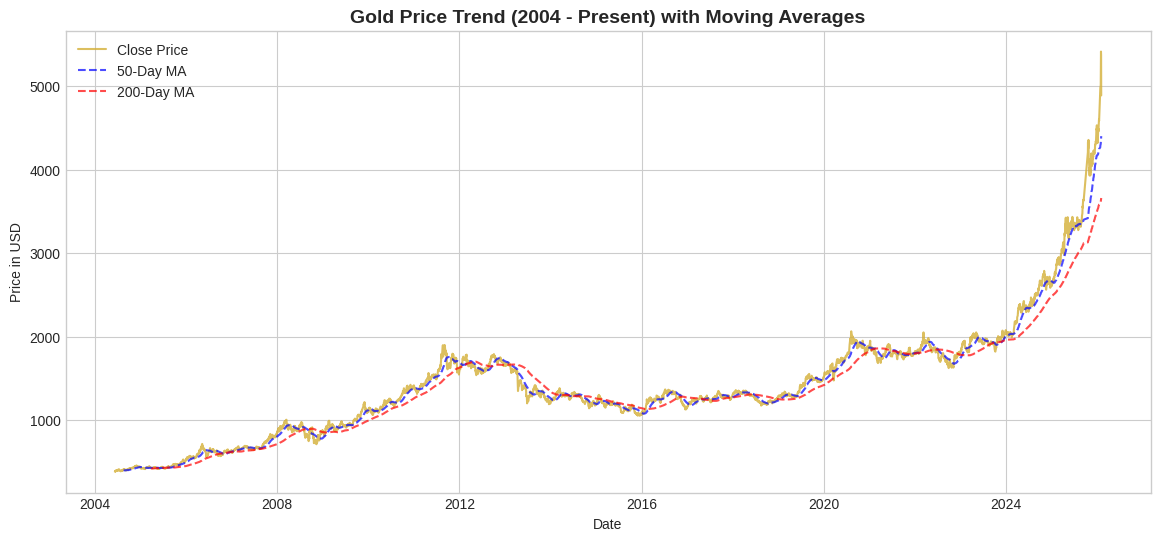

In [19]:
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], label='Close Price', color='#D4AF37', alpha=0.8)
plt.plot(df['Date'], df['MA50'], label='50-Day MA', color='blue', linestyle='--', alpha=0.7)
plt.plot(df['Date'], df['MA200'], label='200-Day MA', color='red', linestyle='--', alpha=0.7)

plt.title('Gold Price Trend (2004 - Present) with Moving Averages', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.legend()
plt.show()

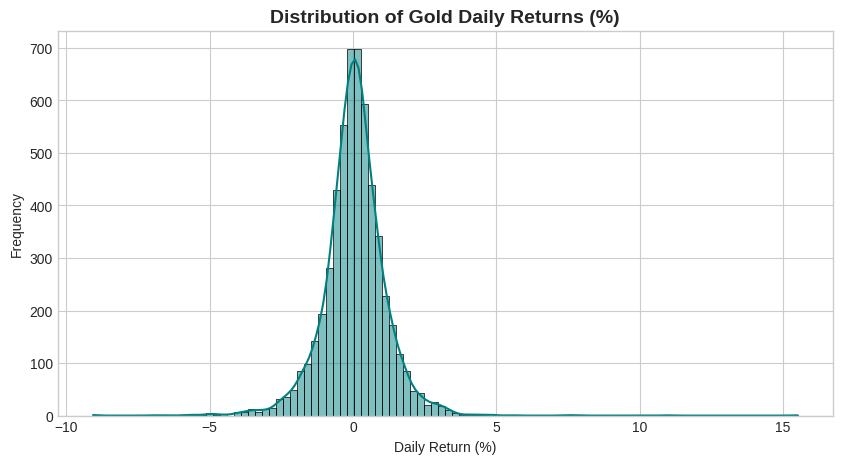

In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Daily_Return_%'].dropna(), bins=100, kde=True, color='teal')
plt.title('Distribution of Gold Daily Returns (%)', fontsize=14, fontweight='bold')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_639/289626535.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_avg.index, y=yearly_avg.values, palette='Blues_d')


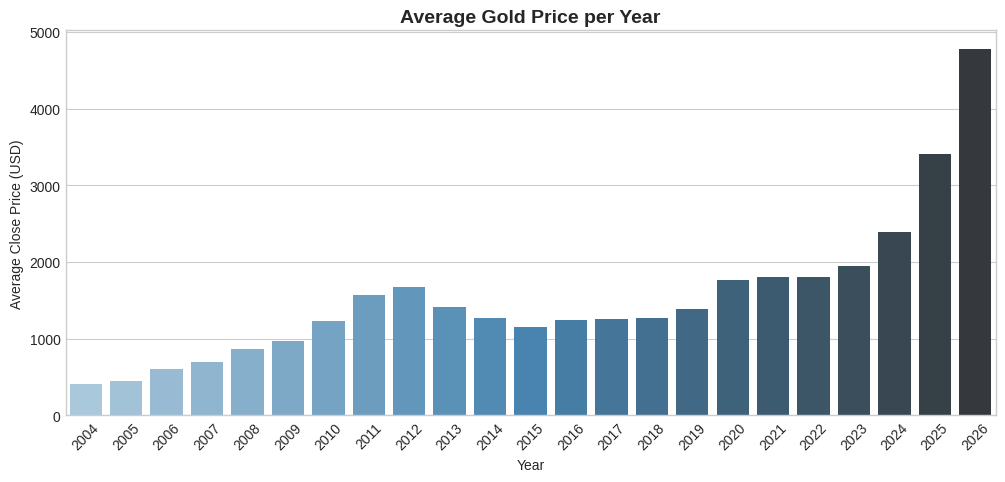

In [21]:
yearly_avg = df.groupby('Year')['Close'].mean()

plt.figure(figsize=(12, 5))
sns.barplot(x=yearly_avg.index, y=yearly_avg.values, palette='Blues_d')
plt.title('Average Gold Price per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Close Price (USD)')
plt.xticks(rotation=45)
plt.show()

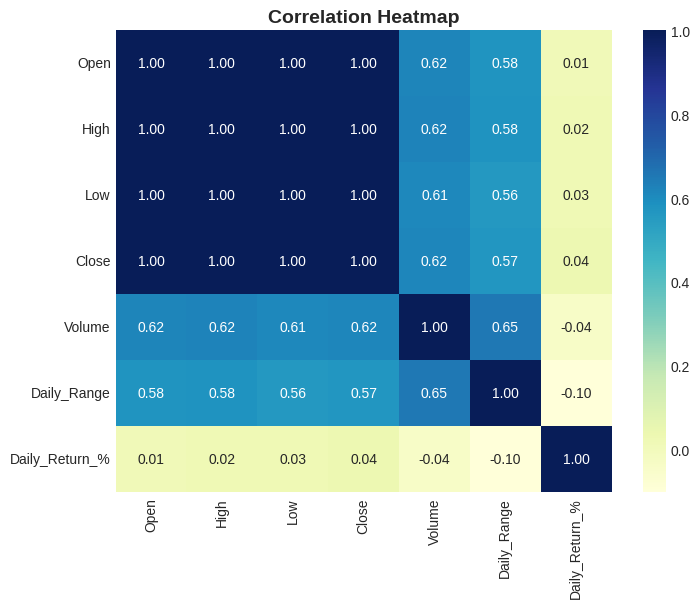

In [22]:
plt.figure(figsize=(8, 6))
numeric_df = df[['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Range', 'Daily_Return_%']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

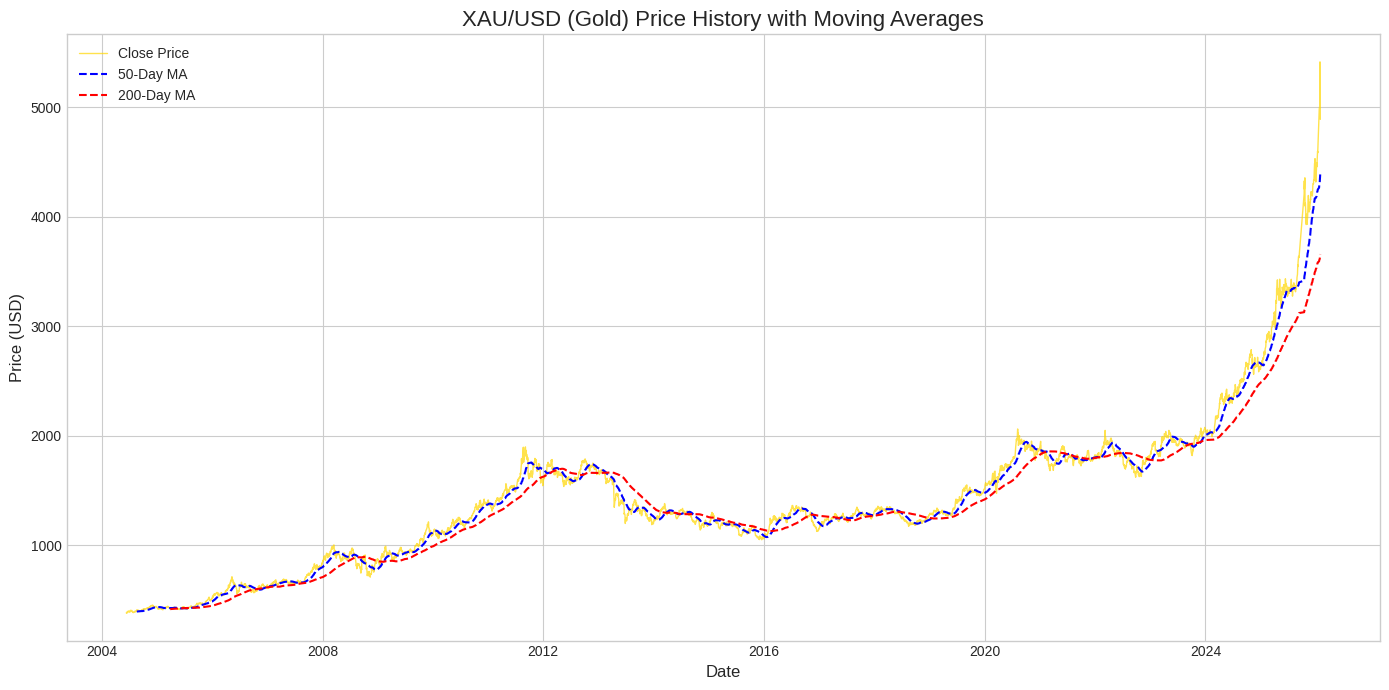

In [23]:
# cell 15
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Close'], label='Close Price', color='gold', alpha=0.7, linewidth=1)
plt.plot(df['Date'], df['MA50'], label='50-Day MA', color='blue', linestyle='--', linewidth=1.5)
plt.plot(df['Date'], df['MA200'], label='200-Day MA', color='red', linestyle='--', linewidth=1.5)

plt.title('XAU/USD (Gold) Price History with Moving Averages', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

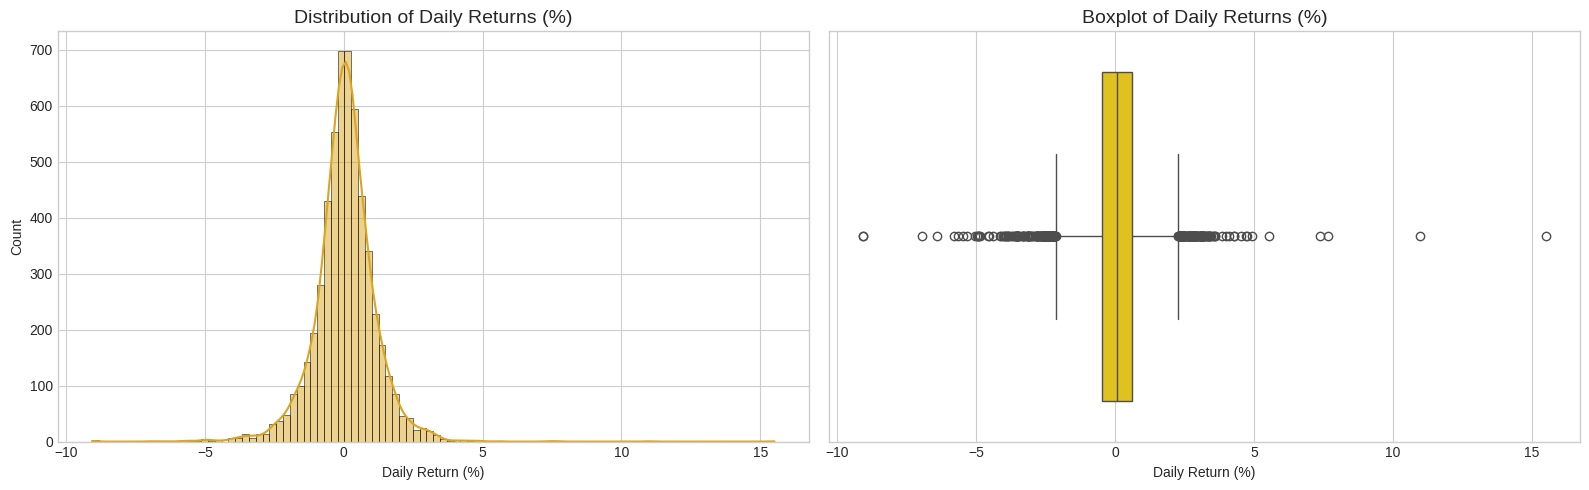

In [24]:
# cell 16
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['Daily_Return_%'].dropna(), kde=True, ax=axes[0], color='goldenrod', bins=100)
axes[0].set_title('Distribution of Daily Returns (%)', fontsize=14)
axes[0].set_xlabel('Daily Return (%)')

# Boxplot
sns.boxplot(x=df['Daily_Return_%'], ax=axes[1], color='gold')
axes[1].set_title('Boxplot of Daily Returns (%)', fontsize=14)
axes[1].set_xlabel('Daily Return (%)')

plt.tight_layout()
plt.show()

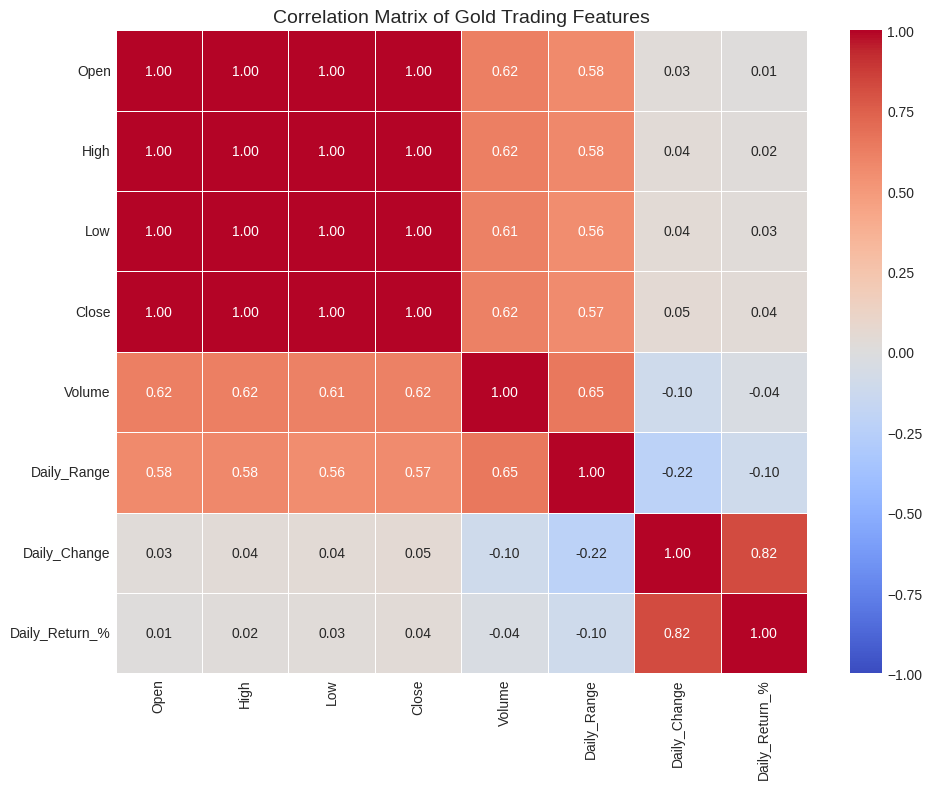

In [25]:
# cell 17
plt.figure(figsize=(10, 8))
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Range', 'Daily_Change', 'Daily_Return_%']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Gold Trading Features', fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_639/1204625425.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='DayOfWeek', y='Daily_Range', order=days_order, ax=axes[0], palette='Blues_d')
/tmp/ipykernel_639/1204625425.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='DayOfWeek', y='Daily_Return_%', order=days_order, ax=axes[1], palette='Oranges_d')


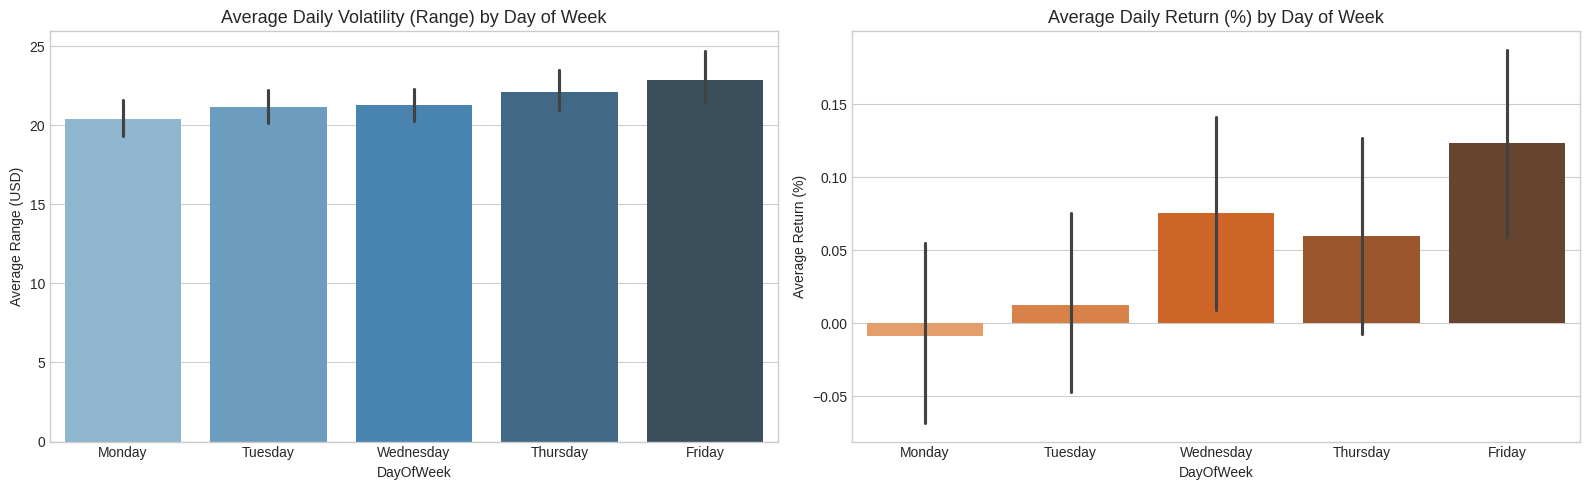

In [26]:
# cell 18
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

# متوسط النطاق اليومي حسب اليوم
sns.barplot(data=df, x='DayOfWeek', y='Daily_Range', order=days_order, ax=axes[0], palette='Blues_d')
axes[0].set_title('Average Daily Volatility (Range) by Day of Week', fontsize=13)
axes[0].set_ylabel('Average Range (USD)')

# متوسط العائد اليومي حسب اليوم
sns.barplot(data=df, x='DayOfWeek', y='Daily_Return_%', order=days_order, ax=axes[1], palette='Oranges_d')
axes[1].set_title('Average Daily Return (%) by Day of Week', fontsize=13)
axes[1].set_ylabel('Average Return (%)')

plt.tight_layout()
plt.show()

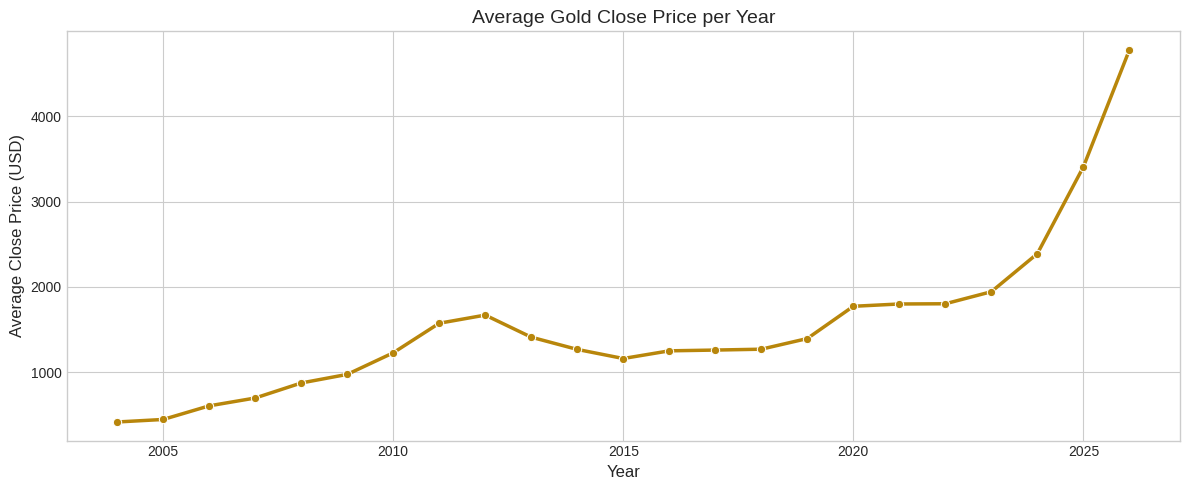

In [27]:
# cell 19
yearly_avg = df.groupby('Year')['Close'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly_avg, x='Year', y='Close', marker='o', color='darkgoldenrod', linewidth=2.5)
plt.title('Average Gold Close Price per Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Close Price (USD)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
# cell 20
# إنشاء ميزات الأيام السابقة (Lags)
df['Close_Lag1'] = df['Close'].shift(1)
df['Close_Lag2'] = df['Close'].shift(2)
df['Close_Lag3'] = df['Close'].shift(3)

# الهدف: سعر الإغلاق لليوم التالي (Target)
df['Target_Next_Close'] = df['Close'].shift(-1)

# حذف الصفوف التي تحتوي على قيم مفقودة بسبب الـ Shift
df_model = df.dropna().copy()

print("Model Dataset Shape:", df_model.shape)
df_model[['Close', 'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'Target_Next_Close']].head()

Model Dataset Shape: (5331, 18)


,Close,Close_Lag1,Close_Lag2,Close_Lag3,Target_Next_Close
199,425.3,425.8,423.8,424.8,425.3
200,425.3,425.3,425.8,423.8,427.8
201,427.8,425.3,425.3,425.8,425.1
202,425.1,427.8,425.3,425.3,423.3
203,423.3,425.1,427.8,425.3,424.0


In [29]:
# cell 21
from sklearn.model_selection import train_test_split

features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Range', 'MA50', 'MA200', 'Close_Lag1', 'Close_Lag2', 'Close_Lag3']
X = df_model[features]
y = df_model['Target_Next_Close']

# تقسيم 80% تدريب و 20% اختبار مع الحفاظ على الترتيب الزمني
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 4264 rows
Testing set size: 1067 rows


In [30]:
# cell 22
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# إنشاء وتدريب النموذج
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# التنبؤ على مجموعة الاختبار
y_pred = model.predict(X_test)

# حساب مقاييس الأداء
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} USD")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} USD")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 476.12 USD
Root Mean Squared Error (RMSE): 825.95 USD
R² Score: -0.3033


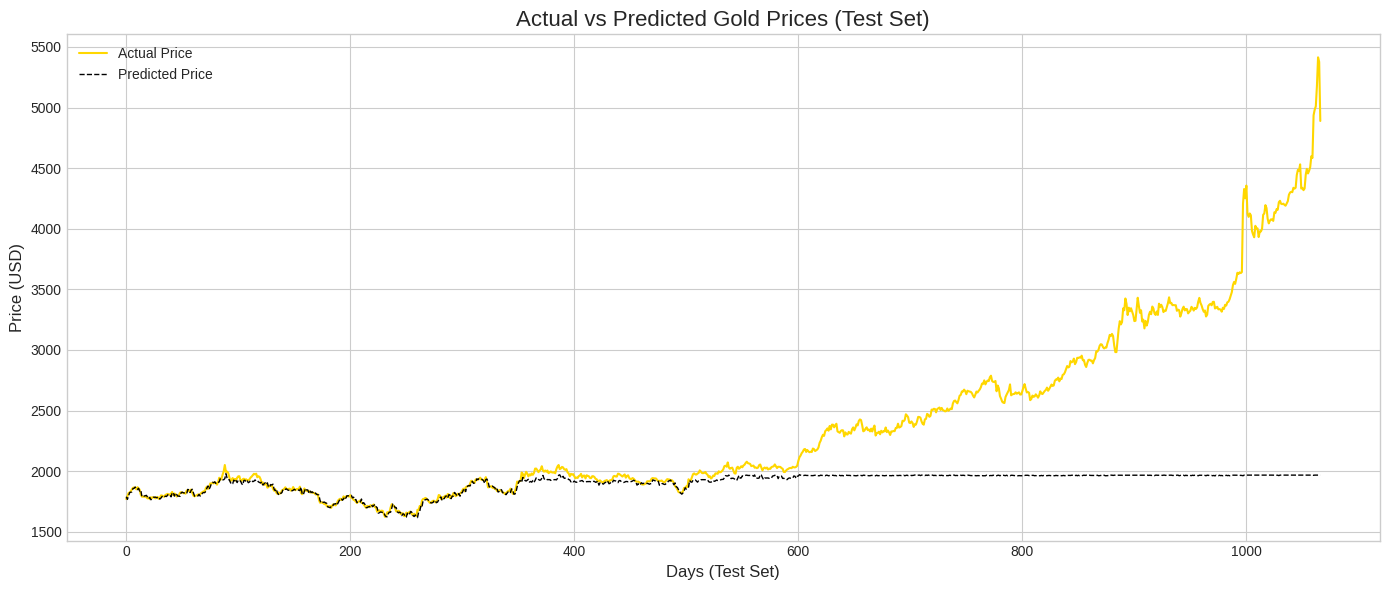

In [31]:
# cell 23
plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label='Actual Price', color='gold', linewidth=1.5)
plt.plot(y_pred, label='Predicted Price', color='black', linestyle='--', linewidth=1)

plt.title('Actual vs Predicted Gold Prices (Test Set)', fontsize=16)
plt.xlabel('Days (Test Set)', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# cell 24
# حساب العائد المستقبلي لليوم التالي كنسبة مئوية
df['Target_Next_Return'] = df['Close'].pct_change().shift(-1)

# تجهيز البيانات وحذف القيم المفقودة
df_model = df.dropna().copy()

features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Range', 'Daily_Return_%', 'MA50', 'MA200']
X = df_model[features]
y = df_model['Target_Next_Return']

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training rows: {len(X_train)}, Testing rows: {len(X_test)}")

Training rows: 4264, Testing rows: 1067


In [33]:
# cell 25
from sklearn.linear_model import Ridge

# استخدام Ridge Regression للاستفادة من الاتجاهات الصاعدة
model_return = Ridge(alpha=1.0)
model_return.fit(X_train, y_train)

# التنبؤ بنسبة العائد
predicted_returns = model_return.predict(X_test)

# إعادة بناء الأسعار المتوقعة بناءً على السعر الحقيقي لليوم السابق
actual_close_test = df_model['Close'].iloc[-len(y_test):].values
predicted_prices = [actual_close_test[0]]

for i in range(1, len(actual_close_test)):
    next_price = predicted_prices[-1] * (1 + predicted_returns[i-1])
    # أو استخدام السعر الفعلي لليوم السابق للتنبؤ بليوم التالي (One-step ahead forecasting):
    # next_price = actual_close_test[i-1] * (1 + predicted_returns[i-1])
    predicted_prices.append(next_price)

print("Return-based forecasting model trained successfully!")

Return-based forecasting model trained successfully!


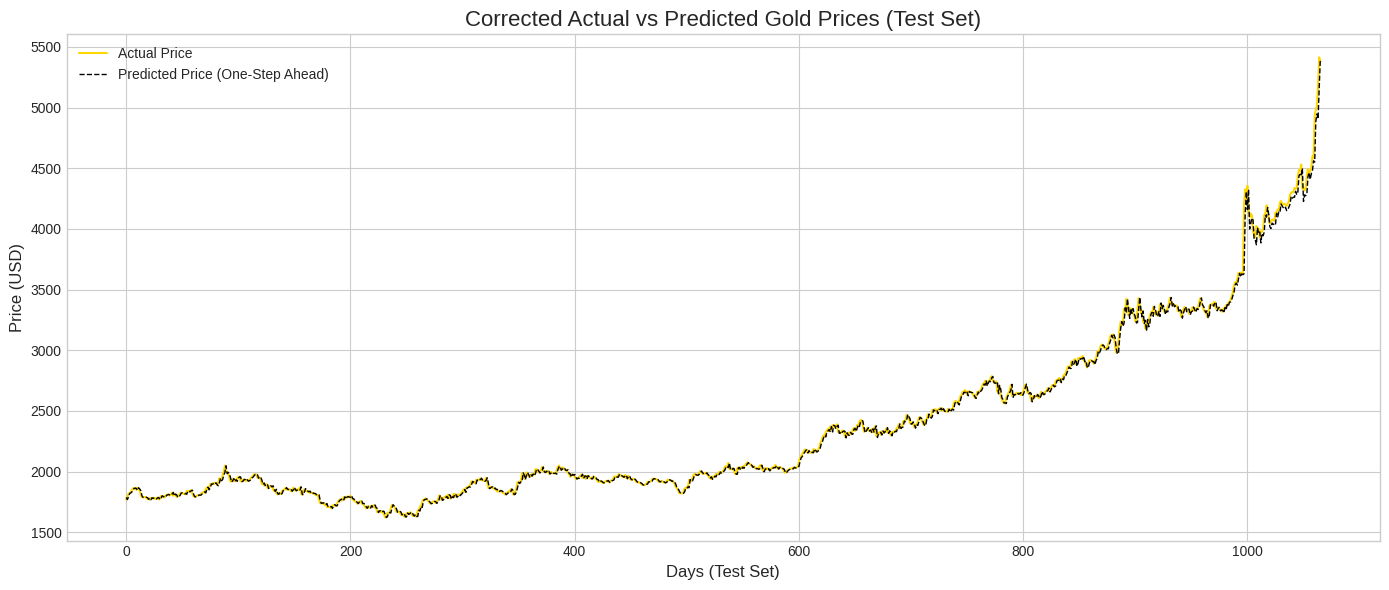

In [34]:
# cell 26
# التنبؤ بخطوة واحدة لكل يوم بناءً على سعر إغلاق اليوم السابق
one_step_preds = actual_close_test[:-1] * (1 + predicted_returns[:-1])

plt.figure(figsize=(14, 6))
plt.plot(actual_close_test[1:], label='Actual Price', color='gold', linewidth=1.5)
plt.plot(one_step_preds, label='Predicted Price (One-Step Ahead)', color='black', linestyle='--', linewidth=1)

plt.title('Corrected Actual vs Predicted Gold Prices (Test Set)', fontsize=16)
plt.xlabel('Days (Test Set)', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# cell 27
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

actual_vals = actual_close_test[1:]
pred_vals = one_step_preds

mae = mean_absolute_error(actual_vals, pred_vals)
rmse = np.sqrt(mean_squared_error(actual_vals, pred_vals))
r2 = r2_score(actual_vals, pred_vals)

print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} USD")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} USD")
print(f"R² Score: {r2:.4f}")

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 21.04 USD
Root Mean Squared Error (RMSE): 38.82 USD
R² Score: 0.9971


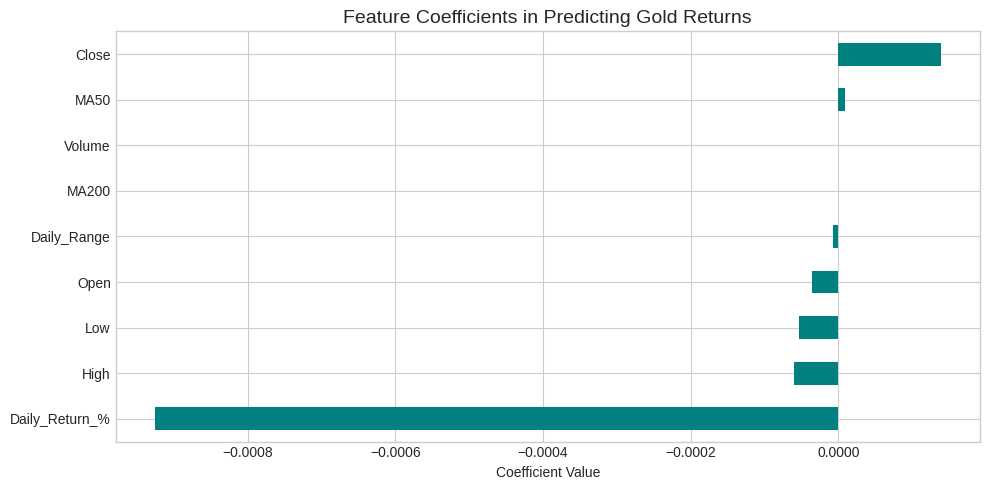

In [36]:
# cell 28
importance = pd.Series(model_return.coef_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
importance.plot(kind='barh', color='teal')
plt.title('Feature Coefficients in Predicting Gold Returns', fontsize=14)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [37]:
# cell 29
# جلب آخر صف من البيانات
latest_data = X.iloc[[-1]]
latest_close = df['Close'].iloc[-1]

# التنبؤ بنسبة التغير لليوم القادم
next_return_pred = model_return.predict(latest_data)[0]
predicted_next_price = latest_close * (1 + next_return_pred)

print(f"Latest Recorded Close Price: ${latest_close:.2f}")
print(f"Predicted Return for Next Day: {next_return_pred * 100:.2f}%")
print(f"Predicted Next Close Price: ${predicted_next_price:.2f}")

Latest Recorded Close Price: $4889.48
Predicted Return for Next Day: -2.53%
Predicted Next Close Price: $4765.82


In [38]:
# cell 30
import joblib

# حفظ النموذج
joblib.dump(model_return, 'gold_price_ridge_model.pkl')

# حفظ البيانات المعالجة في ملف CSV
df_model.to_csv('processed_gold_data.csv', index=False)

print("Model and Processed Data saved successfully!")

Model and Processed Data saved successfully!
